NLP 1ST PROJECT


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re #regular expression cleaning data
import nltk# for basics
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

#download required nltk files
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

step 2: create sample customer reviews

In [49]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)
print("customer Reviews dataset")
print(df.head())


customer Reviews dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [50]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()
    print('lower case', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print('special character', text)

    # Tokenization
    words = word_tokenize(text)
    print('tokenization', words)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    print('stopwords',words)

    cleaned_text = ' '.join(words)
    return cleaned_text
df['cleaned_review'] = df['Review'].apply(clean_text)

print("\ncleaned reviews")
print(df['cleaned_review'])


lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delivery'

sentiment analysis

In [51]:
sia = SentimentIntensityAnalyzer()
def  analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >=0.05:
    return "Positive"
  elif compound <= -0.05:
    return "Negative"
  else:
    return "Neutral"
df['Sentiment'] = df['cleaned_review'].apply(analyze_sentiment)
print('\n sentiment analysis Results:')
print(df[['Review','Sentiment']])


 sentiment analysis Results:
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


STEP :- FIND COMMON KEYWORDS

In [52]:
from collections import Counter

# Combine all cleaned reviews
all_words = " ".join(df['cleaned_review'])

# Convert text into list of words
word_list = all_words.split()

# Count word frequency
word_freq = Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [46]:
Negative_reviews = df[df['Sentiment'] == 'Negative']

Negative_words = " ".join(Negative_reviews['cleaned_review'])

Negative_word_list = Negative_words.split()

complaint_freq = Counter(Negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


STEP 7 :-  VISUALIZATION  

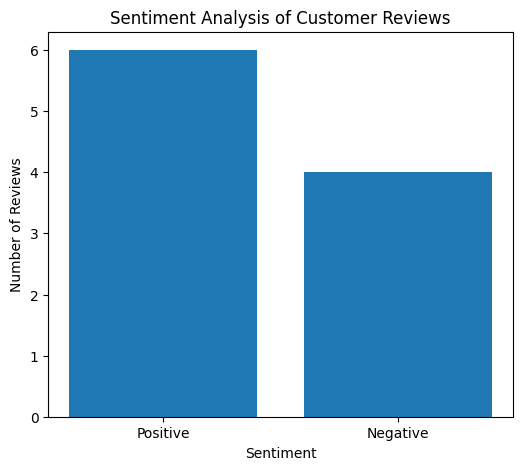

In [47]:
sentiment_counts = df['Sentiment'].value_counts()  # it will give

plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Analysis of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

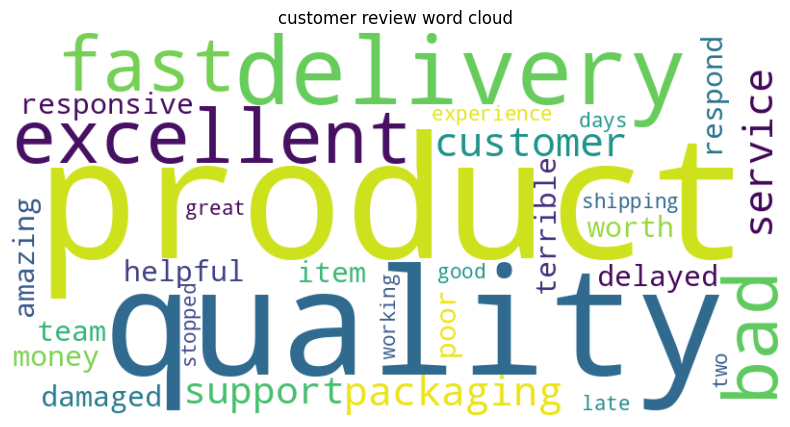

In [55]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("customer review word cloud")
plt.show()
